In [1]:
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import *
import chardet
import datetime

In [2]:
data_players = pd.read_csv('data_players.csv')
data_match_scores = pd.read_csv('match_scores.csv')
data_match_stats = pd.read_csv('match_stats.csv')
data_rankings_1 = pd.read_csv('rankings.csv')
data_rankings_2=pd.read_csv('rankings_2.csv')
data_rankings_3=pd.read_csv('rankings_3.csv')
data_rankings=pd.concat([data_rankings_1,data_rankings_2,data_rankings_3])
annee_debut=1960
diametre_balle=6.5
players_non_retraites=data_players.birth_year>=annee_debut
players_taille_ok=data_players.height_cm>diametre_balle
data_players_choisis=data_players[players_non_retraites & players_taille_ok]

160.0 220.0
[160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215.]


(array([  1.,  13., 103., 342., 657., 626., 364.,  90.,  20.,   2.,   2.]),
 array([160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210.,
        215.]),
 <BarContainer object of 11 artists>)

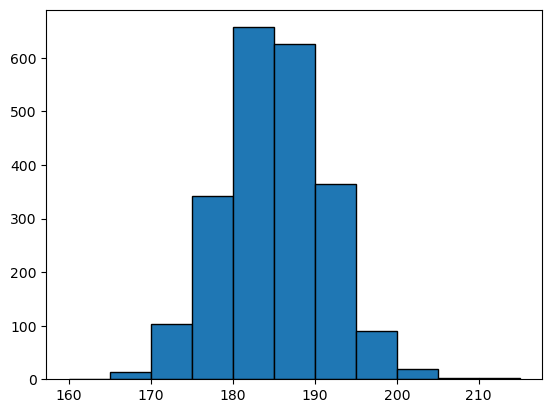

In [3]:
###HISTOGRAMME TAILLES
annee_debut=1960
tailles = data_players_choisis["height_cm"]
xmingraph = np.floor(tailles.min()/5)*5
xmaxgraph = np.floor(tailles.max()/5)*5+5*2
print(xmingraph,xmaxgraph)
liste_bornes=np.arange(xmingraph,xmaxgraph,5)
print(liste_bornes)
plt.hist(data_players_choisis["height_cm"],bins=liste_bornes,ec="black")



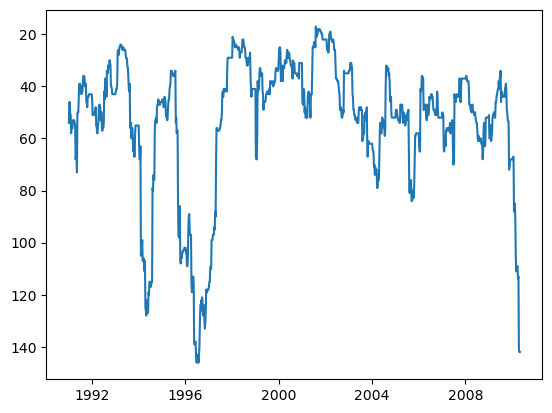

In [4]:
###Graphique évolution classement
joueur_voulu='s424'


datavoulue = data_rankings.loc[(data_rankings["player_id"]==joueur_voulu)]

datavoulue = datavoulue.sort_values(by="week_title")
x_graph=np.char.replace(datavoulue.week_title.values.astype('str'),'.','-').astype('datetime64')
plt.gca().invert_yaxis()
plt.plot(x_graph,datavoulue["rank_number"])
#Pour avoir son vecteur de données en abscisses après avoir trié selon week_title pour obtenir dates:
#x_graph=np.char.replace(dates.values.astype('str'),'.','-').astype('datetime64')

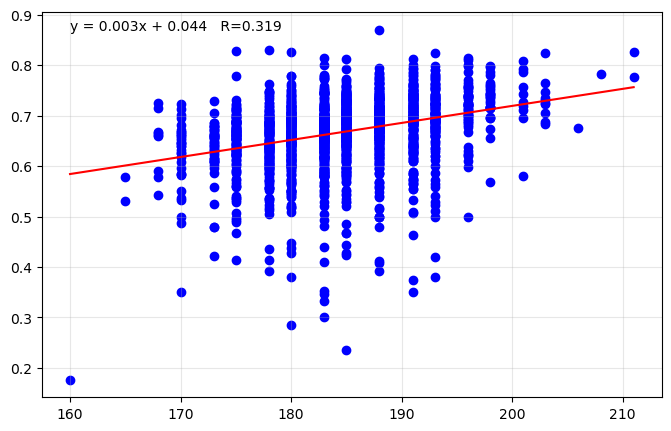

1921


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = data_match_stats.merge(
    data_match_scores[["match_id", "winner_player_id", "loser_player_id"]], on="match_id"
)
roles = [("winner_player_id", "winner_first_serve_points_won", "winner_first_serve_points_total"),
         ("loser_player_id",  "loser_first_serve_points_won",  "loser_first_serve_points_total")]
services = (
    pd.concat([df[[pid, won, tot]].rename(columns={pid: "player_id", won: "won", tot: "total"})
               for pid, won, tot in roles])
    .dropna()
    .groupby("player_id", as_index=False).sum()
)
services["rate"] = services["won"] / services["total"]
df_final = (data_players_choisis[["player_id", "height_cm"]]
            .merge(services, on="player_id")
            .query("total > 0"))
x, y = df_final["height_cm"], df_final["rate"]
pente, b = np.polyfit(x, y, 1)
corr = x.corr(y)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="blue")
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, pente * xx + b, color="red")
plt.text(x.min(), y.max(), f"y = {pente:.3f}x + {b:.3f}   R={corr:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

print(df_final["player_id"].count())